# 미션 10. 구독 서비스 결제 페이지 A/B 테스트 분석

## 1. 분석 배경
회사는 단기적인 현금흐름 개선이 필요한 상황이며, 이를 위해 12개월 멤버십 결제 비율을 높이고자 한다.  
DA 팀은 결제 페이지의 멤버십 옵션 제시 방식을 변경하여, 사용자가 12개월 플랜을 더 많이 선택하도록 유도하는 실험을 진행했다.

- **A안(기존안)**: 1개월 / 12개월 가격을 단순 비교
- **B안(변경안)**: 12개월 멤버십의 월간 가격을 강조하여 경제성을 부각

## 2. 실험 가설
12개월 멤버십의 월간 가격을 강조하면, 사용자는 12개월 멤버십을 더 많이 선택할 것이다.

## 3. 분석 목표
이번 분석에서는 아래 질문에 답하고자 한다.

1. B안이 A안보다 **전체 구독 전환율**을 높였는가?
2. B안이 A안보다 **12개월 구독 선택**을 증가시켰는가?
3. B안이 A안보다 **방문자당 매출(RPU)** 및 **단기 현금 유입**을 개선했는가?
4. 위 결과를 바탕으로 **B안을 채택할지 여부**를 결정한다.

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
#!pip -q install koreanize-matplotlib
import koreanize_matplotlib
file_path = '/content/drive/MyDrive/코드잇_DA_13기_이현재/30%20Day%20Subscription%20Data.csv'
df=pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            60 non-null     int64  
 1   Date                  60 non-null     object 
 2   Total Users           60 non-null     int64  
 3   Subscribers           60 non-null     int64  
 4   1-Month Subscribers   60 non-null     int64  
 5   12-Month Subscribers  60 non-null     int64  
 6   Revenue               60 non-null     int64  
 7   Group                 60 non-null     object 
 8   Conversion Rate       60 non-null     float64
 9   1-Month Revenue       60 non-null     int64  
 10  12-Month Revenue      60 non-null     int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 5.3+ KB
None


In [90]:
df.describe()

,Unnamed: 0,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,Conversion Rate,1-Month Revenue,12-Month Revenue
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.00000
mean,14.500000,507.450000,29.666667,24.183333,5.483333,2458.516667,0.058497,846.416667,1612.10000
std,8.728484,42.213109,5.697655,4.515479,2.062512,687.849917,0.010425,158.041755,606.37846
min,0.000000,424.000000,20.000000,17.000000,2.000000,1323.000000,0.044944,595.000000,588.00000
25%,7.000000,480.500000,25.000000,20.000000,4.000000,1867.250000,0.048701,700.000000,1176.00000
50%,14.500000,512.000000,30.000000,24.000000,5.000000,2415.000000,0.055037,840.000000,1470.00000
75%,22.000000,528.750000,35.000000,28.000000,7.000000,2924.250000,0.068341,980.000000,2058.00000
max,29.000000,607.000000,39.000000,35.000000,11.000000,4214.000000,0.077381,1225.000000,3234.00000


In [91]:
df.head(60)

,Unnamed: 0,Date,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,Group,Conversion Rate,1-Month Revenue,12-Month Revenue
0,0,2023.9.15,459,22,19,3,1547,A,0.047930,665,882
1,1,2023.9.16,504,26,21,5,2205,A,0.051587,735,1470
2,2,2023.9.17,514,26,22,4,1946,A,0.050584,770,1176
3,3,2023.9.18,482,23,19,4,1841,A,0.047718,665,1176
4,4,2023.9.19,512,25,19,6,2429,A,0.048828,665,1764
5,5,2023.9.20,490,24,20,4,1876,A,0.048980,700,1176
6,6,2023.9.21,539,25,23,2,1393,A,0.046382,805,588
7,7,2023.9.22,450,21,18,3,1512,A,0.046667,630,882
8,8,2023.9.23,446,22,18,4,1806,A,0.049327,630,1176
9,9,2023.9.24,540,25,21,4,1911,A,0.046296,735,1176


In [92]:
df=df.drop(columns=['Unnamed: 0'])
df['Date']=pd.to_datetime(df['Date'].str.replace('.','-'))
df

,Date,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,Group,Conversion Rate,1-Month Revenue,12-Month Revenue
0,2023-09-15,459,22,19,3,1547,A,0.047930,665,882
1,2023-09-16,504,26,21,5,2205,A,0.051587,735,1470
2,2023-09-17,514,26,22,4,1946,A,0.050584,770,1176
3,2023-09-18,482,23,19,4,1841,A,0.047718,665,1176
4,2023-09-19,512,25,19,6,2429,A,0.048828,665,1764
5,2023-09-20,490,24,20,4,1876,A,0.048980,700,1176
6,2023-09-21,539,25,23,2,1393,A,0.046382,805,588
7,2023-09-22,450,21,18,3,1512,A,0.046667,630,882
8,2023-09-23,446,22,18,4,1806,A,0.049327,630,1176
9,2023-09-24,540,25,21,4,1911,A,0.046296,735,1176


## 1. 데이터 분석 준비

실험 데이터를 날짜별로 분석하여 A안과 B안의 차이를 확인한다.  
이번 단계에서는 다음 세 가지를 중심으로 살펴본다.

- 날짜별 1개월 구독자 수 변화
- 날짜별 12개월 구독자 수 변화
- 날짜별 수익 변화

이를 통해 두 실험안이 실험 기간 동안 어떤 흐름을 보였는지 먼저 확인한다.

In [93]:
날짜별df=df.groupby(['Date','Group'])[['Total Users','Subscribers','1-Month Subscribers','12-Month Subscribers','Revenue']].sum().reset_index()
날짜별df.head(5)

,Date,Group,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue
0,2023-09-15,A,459,22,19,3,1547
1,2023-09-15,B,516,35,28,7,3038
2,2023-09-16,A,504,26,21,5,2205
3,2023-09-16,B,483,33,24,9,3486
4,2023-09-17,A,514,26,22,4,1946


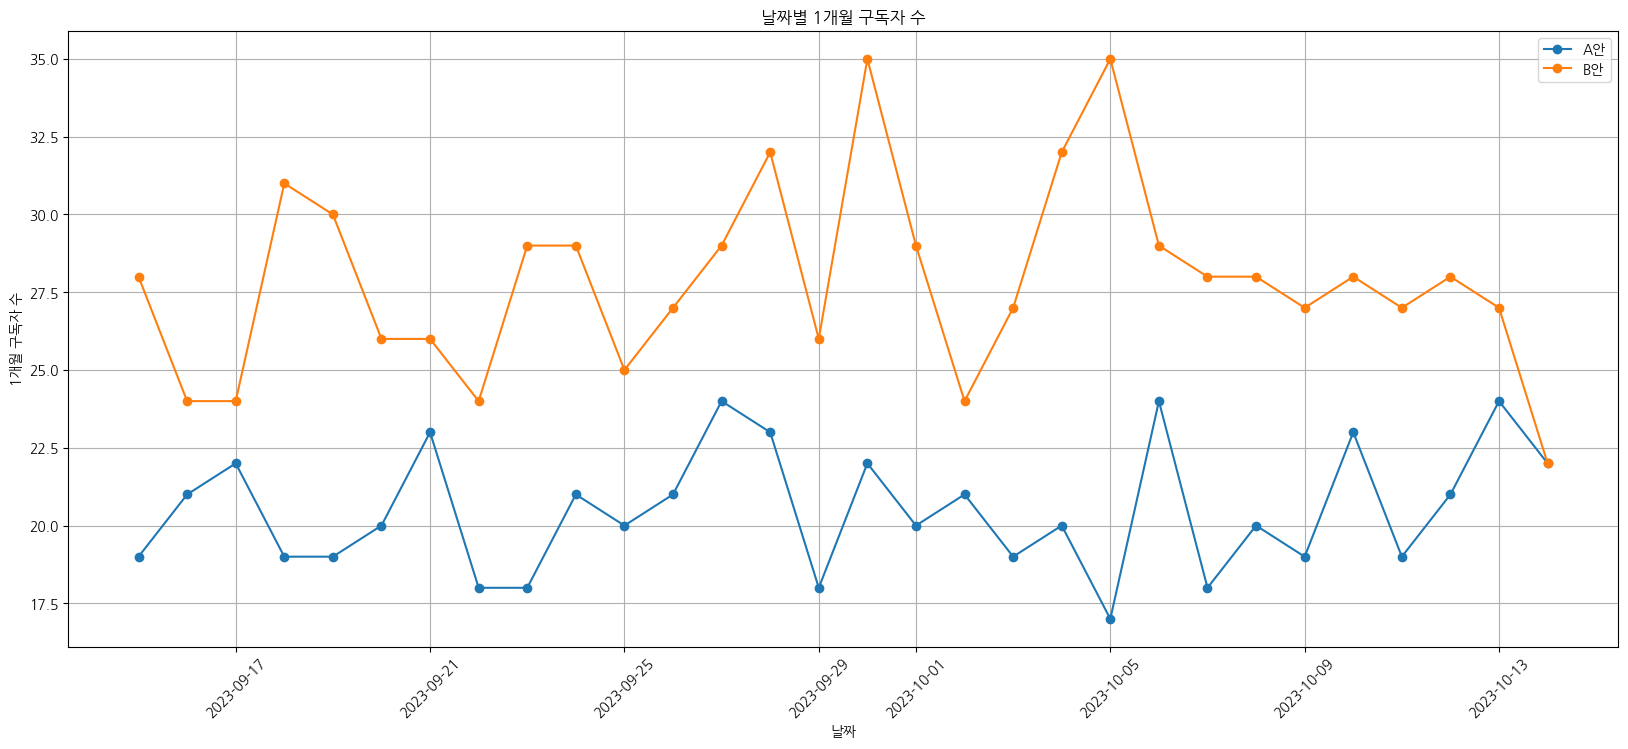

In [94]:
날짜별1개월구독자수 = 날짜별df.pivot(index='Date', columns='Group', values='1-Month Subscribers')

plt.figure(figsize=(20,8))
plt.plot(날짜별1개월구독자수.index, 날짜별1개월구독자수['A'], marker='o', label='A안')
plt.plot(날짜별1개월구독자수.index, 날짜별1개월구독자수['B'], marker='o', label='B안')

plt.title('날짜별 1개월 구독자 수')
plt.xlabel('날짜')
plt.ylabel('1개월 구독자 수')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

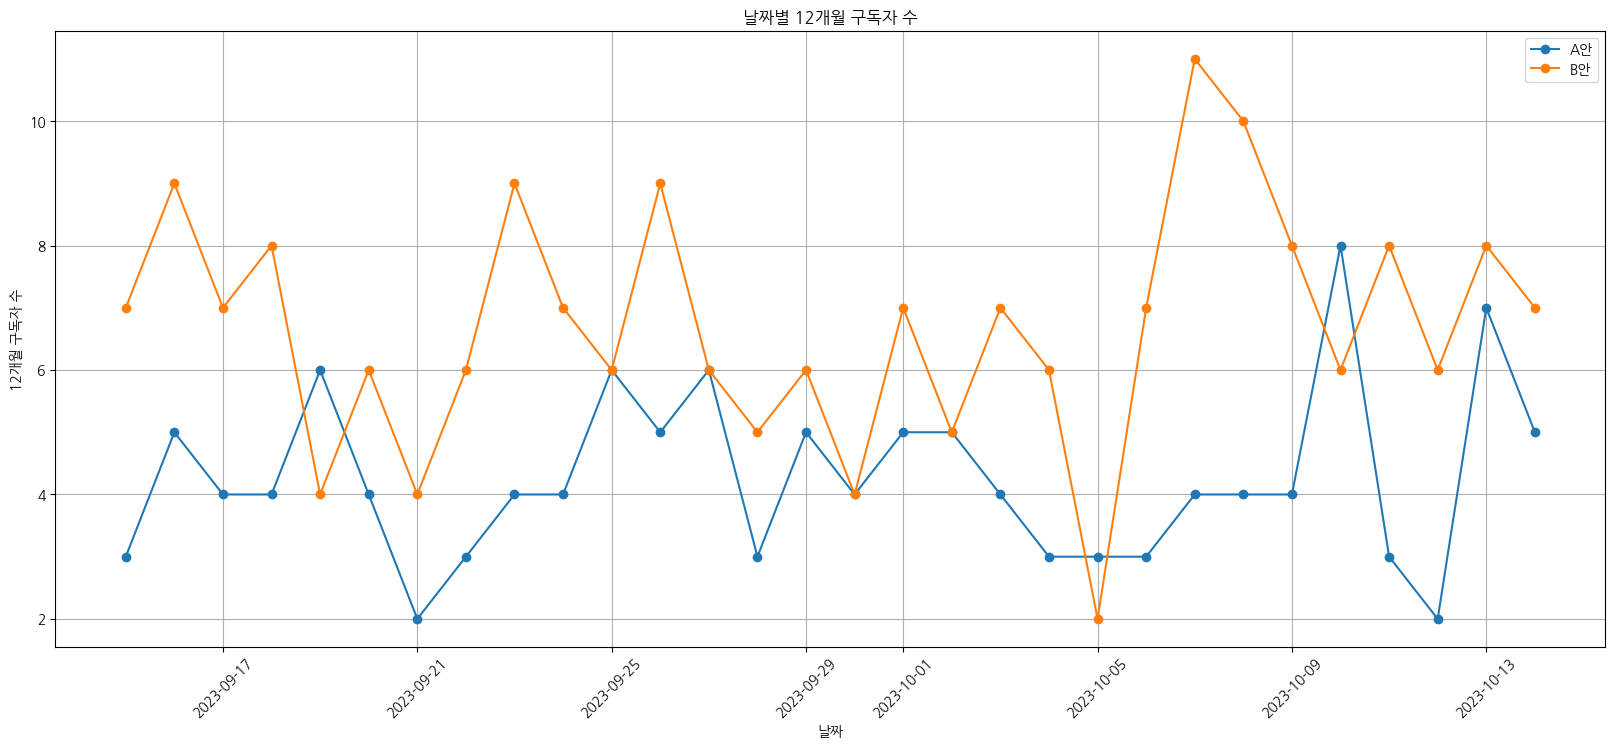

In [95]:
날짜별12개월구독자수 = 날짜별df.pivot(index='Date', columns='Group', values='12-Month Subscribers')

plt.figure(figsize=(20,8))
plt.plot(날짜별12개월구독자수.index, 날짜별12개월구독자수['A'], marker='o', label='A안')
plt.plot(날짜별12개월구독자수.index, 날짜별12개월구독자수['B'], marker='o', label='B안')

plt.title('날짜별 12개월 구독자 수')
plt.xlabel('날짜')
plt.ylabel('12개월 구독자 수')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

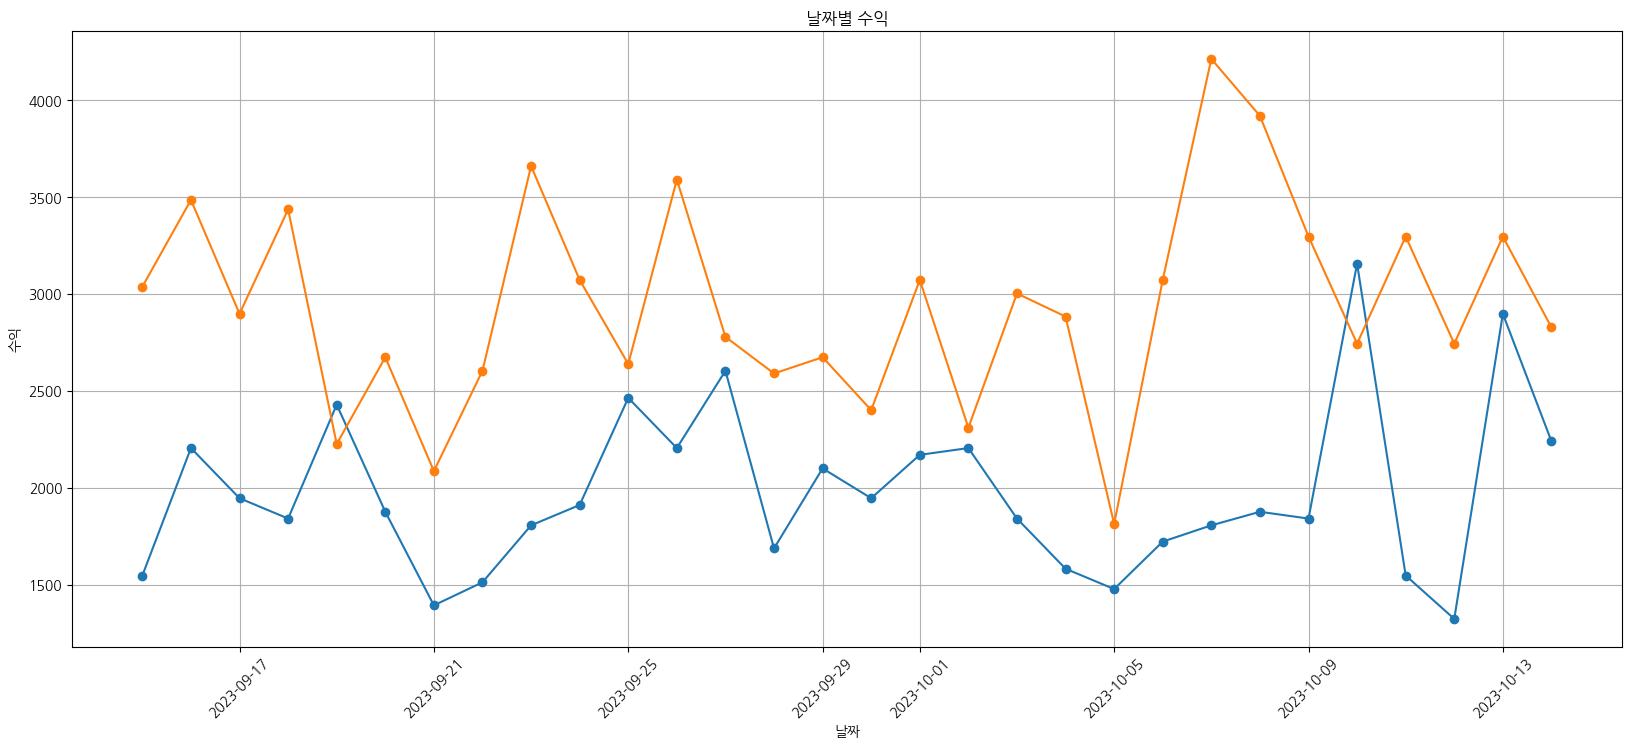

In [96]:
수익별그래프=날짜별df.pivot(index='Date', columns='Group', values='Revenue')
plt.figure(figsize=(20,8)) # 사이즈를 먼저 지정 안하면 빈그래프가 생기는걸 여기 통해 알았다....
plt.plot(수익별그래프.index, 수익별그래프['A'], marker='o',label='A안')
plt.plot(수익별그래프.index, 수익별그래프['B'], marker='o',label='B안')


plt.title('날짜별 수익')
plt.xlabel('날짜')
plt.ylabel('수익')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [97]:
sum_df = df.groupby('Group')[['Total Users', 'Subscribers', '1-Month Subscribers', '12-Month Subscribers', 'Revenue']].sum()
sum_df

,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue
Group,,,,,
A,15265,743,615,128,59157
B,15182,1037,836,201,88354


In [98]:
sum_df['전환율'] = sum_df['Subscribers'] / sum_df['Total Users']
sum_df['12개월 구독 비율'] = sum_df['12-Month Subscribers'] / sum_df['Subscribers']
sum_df['1인당 기대수익'] = sum_df['Revenue'] / sum_df['Total Users']
sum_df

,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,전환율,12개월 구독 비율,1인당 기대수익
Group,,,,,,,,
A,15265,743,615,128,59157,0.048673,0.172275,3.875336
B,15182,1037,836,201,88354,0.068305,0.193828,5.819655


In [99]:
sum_df2 =sum_df.copy()
sum_df2['전환율'] = (sum_df2['전환율']*100).round(2)
sum_df2['12개월 구독 비율'] = (sum_df2['12개월 구독 비율']*100).round(2)
sum_df2['1인당 기대수익'] = sum_df2['1인당 기대수익'].round(2)
sum_df2

,Total Users,Subscribers,1-Month Subscribers,12-Month Subscribers,Revenue,전환율,12개월 구독 비율,1인당 기대수익
Group,,,,,,,,
A,15265,743,615,128,59157,4.87,17.23,3.88
B,15182,1037,836,201,88354,6.83,19.38,5.82


In [100]:
from scipy.stats import norm
from math import sqrt
from IPython.display import display
import pandas as pd

# 비율 검정 함수
def 비율검정(A성공, A전체, B성공, B전체):
    A비율 = A성공 / A전체
    B비율 = B성공 / B전체
    전체비율 = (A성공 + B성공) / (A전체 + B전체)
    표준오차 = sqrt(전체비율 * (1 - 전체비율) * (1 / A전체 + 1 / B전체))
    z값 = (B비율 - A비율) / 표준오차
    p값 = 2 * (1 - norm.cdf(abs(z값)))
    return A비율, B비율, z값, p값

A안 = sum_df.loc['A']
B안 = sum_df.loc['B']

# 1. 전체 전환율 검정
전환율_a, 전환율_b, 전환율_z, 전환율_p = 비율검정(
    A안['Subscribers'], A안['Total Users'],
    B안['Subscribers'], B안['Total Users']
)

# 2. 12개월 구독 비율 검정
구독비율_a, 구독비율_b, 구독비율_z, 구독비율_p = 비율검정(
    A안['12-Month Subscribers'], A안['Subscribers'],
    B안['12-Month Subscribers'], B안['Subscribers']
)

결과표 = pd.DataFrame({
    '분석항목': ['전체 전환율', '12개월 구독 비율'],
    'A안': [전환율_a * 100, 구독비율_a * 100],
    'B안': [전환율_b * 100, 구독비율_b * 100],
    '차이(B-A)': [(전환율_b - 전환율_a) * 100, (구독비율_b - 구독비율_a) * 100],
    'z값': [전환율_z, 구독비율_z],
    'p값': [전환율_p, 구독비율_p]
})

결과표['A안'] = 결과표['A안'].round(2)
결과표['B안'] = 결과표['B안'].round(2)
결과표['차이(B-A)'] = 결과표['차이(B-A)'].round(2)
결과표['z값'] = 결과표['z값'].round(4)
결과표['p값'] = 결과표['p값'].round(6)

In [101]:
print('=' * 60)
print('통계 검정 결과')
print('=' * 60)
display(결과표)
print('=' * 60)

print('핵심 수치 요약')
print('=' * 60)
print(f"A안 전환율         : {전환율_a*100:.2f}%")
print(f"B안 전환율         : {전환율_b*100:.2f}%")
print(f"A안 12개월 구독 비율 : {구독비율_a*100:.2f}%")
print(f"B안 12개월 구독 비율 : {구독비율_b*100:.2f}%")
print(f"A안 총수익         : {A['Revenue']:.0f}")
print(f"B안 총수익         : {B['Revenue']:.0f}")
print(f"A안 인당수익       : {A['인당수익']:.2f}")
print(f"B안 인당수익       : {B['인당수익']:.2f}")

print('=' * 60)
print('최종 결론')
print('=' * 60)

if (B['Revenue'] > A['Revenue']) and (전환율_p < 0.05) and (전환율_b > 전환율_a):
    print('B안은 A안보다 전환율이 더 높고, 총수익도 더 크게 나타났다.')
    print('따라서 단기 현금흐름 개선이라는 목표를 고려할 때 B안을 채택하는 것이 합리적이다.')

    if 구독비율_p < 0.05 and 구독비율_b > 구독비율_a:
        print('또한 12개월 구독 비율 역시 유의미하게 증가하여 실험 가설도 지지된다고 볼 수 있다.')
    else:
        print('다만 12개월 구독 비율의 차이는 통계적으로 강하다고 보기 어려워, 이 부분은 추가 실험이 필요하다.')
else:
    print('B안이 A안보다 명확하게 우수하다고 단정하기 어렵다.')
    print('따라서 현재 단계에서는 추가 실험을 통해 결과를 다시 확인할 필요가 있다.')

통계 검정 결과


,분석항목,A안,B안,차이(B-A),z값,p값
0,전체 전환율,4.87,6.83,1.96,7.3001,0.000000
1,12개월 구독 비율,17.23,19.38,2.16,1.1553,0.247977


핵심 수치 요약
A안 전환율         : 4.87%
B안 전환율         : 6.83%
A안 12개월 구독 비율 : 17.23%
B안 12개월 구독 비율 : 19.38%
A안 총수익         : 59157
B안 총수익         : 88354
A안 인당수익       : 3.88
B안 인당수익       : 5.82
최종 결론
B안은 A안보다 전환율이 더 높고, 총수익도 더 크게 나타났다.
따라서 단기 현금흐름 개선이라는 목표를 고려할 때 B안을 채택하는 것이 합리적이다.
다만 12개월 구독 비율의 차이는 통계적으로 강하다고 보기 어려워, 이 부분은 추가 실험이 필요하다.
